cost function : RSS 최소화 + 회귀 계수 값 적당히 제어 (과적합 방지) 해야 함.  
cost function 목표 : Min(RSS(w)+alpha*||W||2)  
alpha가 작다면 rss(w)를 최소화하면 되고, alpha가 크다면, 회귀 계수 w를 0에 가깝게 최소화해야 한다.

<릿지 회귀> : L2 Regulation  
Loss Ridge = 오차 제곱합 + alpha * w**2의 합  
alpha : 규제 강도 조절  
w : 각 특성의 계수  
alpha=0 : 일반 선형 회귀  
alpha가 클수록 패널티가 커져서 계수가 더 작아짐 (규제 높아진다)  
릿지 회귀는 모든 계수를 0에 가깝게 만들면서도 모든 특성을 유지함. 안정적인 예측 제공.

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

bostonDF = pd.read_csv('BostonHousing.csv')
bostonDF.rename(columns={'crim':'CRIM', 'zn':'ZN', 'indus':'INDUS', 'chas':'CHAS', 'nox':'NOX', 'rm':'RM', 'age':'AGE', 'dis':'DIS', 
                         'rad':'RAD', 'tax':'TAX', 'ptratio':'PTRATIO', 'b':'B', 'lstat':'LSTAT', 'medv':'PRICE'}, inplace=True)

bostonDF['RM'].fillna(bostonDF['RM'].mean(), inplace=True)


y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace = False)

print(X_data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64


In [56]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha=10으로 설정해 릿지 회귀수행
ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = "neg_mean_squared_error",cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print('5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print('5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print('5 folds의 개별 평균 RMSE: {0:.3f}'.format(avg_rmse))

5 folds의 개별 Negative MSE scores:  [-11.656 -24.373 -28.3   -74.564 -28.572]
5 folds의 개별 RMSE scores:  [3.414 4.937 5.32  8.635 5.345]
5 folds의 개별 평균 RMSE: 5.530


In [58]:
# 릿지에 사용될 alpha값 변화
alphas = [0,0.1,1,10,100]

for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = "neg_mean_squared_error",cv=5)
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)

    print('alpha {0} 일 때 5 folds의 평균 RMSE : {1:.3f}'.format(alpha,avg_rmse))

alpha 0 일 때 5 folds의 평균 RMSE : 5.840
alpha 0.1 일 때 5 folds의 평균 RMSE : 5.800
alpha 1 일 때 5 folds의 평균 RMSE : 5.666
alpha 10 일 때 5 folds의 평균 RMSE : 5.530
alpha 100 일 때 5 folds의 평균 RMSE : 5.336


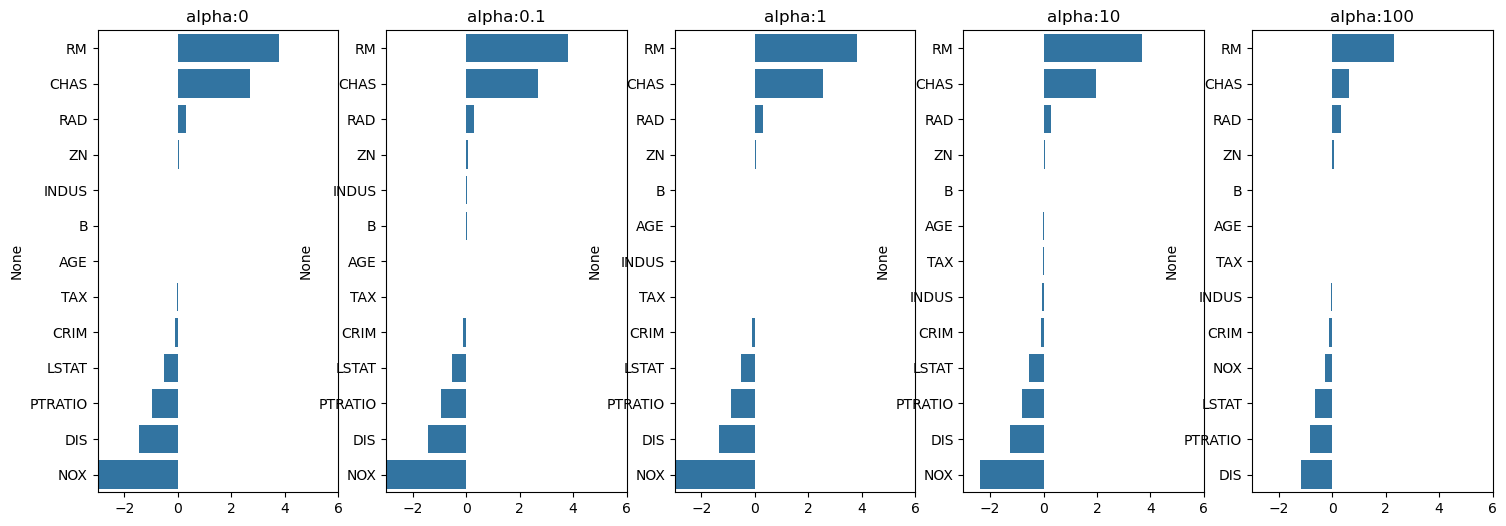

In [66]:
# alpha 값에 따른 회귀 계수 값 시각화
fig, axs = plt.subplots(figsize=(18,6),nrows=1,ncols=5)
coeff_df=pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge=Ridge(alpha=alpha)
    ridge.fit(X_data,y_target)
    coeff=pd.Series(data=ridge.coef_, index=X_data.columns)
    colname='alpha:'+str(alpha)
    coeff_df[colname] = coeff
    coeff = coeff.sort_values(ascending = False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values,y=coeff.index,ax=axs[pos])

plt.show()

위 그래프에서 alpha값이 커질수록 회귀 계수 값은 지속적으로 작아진다.

In [73]:
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending = False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.791638,3.800255,3.837370,3.687519,2.322956
CHAS,2.687541,2.670827,2.553202,1.952688,0.638502
RAD,0.307896,0.305365,0.292008,0.281405,0.316517
ZN,0.046482,0.046631,0.047493,0.049621,0.054557
INDUS,0.021963,0.017423,-0.007274,-0.041385,-0.051939
B,0.009311,0.009368,0.009673,0.010037,0.009391
AGE,0.000964,0.000004,-0.005135,-0.010430,0.001382
TAX,-0.012426,-0.012512,-0.013002,-0.014077,-0.015909
CRIM,-0.108055,-0.107518,-0.104645,-0.101495,-0.102257
LSTAT,-0.525855,-0.527042,-0.534304,-0.560170,-0.661398


<라쏘 회귀> : L1 Regulation  
Loss Lasso = 오차 제곱합 + alpha * w의 절댓값의 합  
alpha : 규제 강도 조절  
w : 각 특성의 계수  
alpha=0 : 일반 선형 회귀  
alpha가 클수록 패널티가 커져서 계수가 더 작아짐 (규제 높아진다)  
라쏘 회귀는 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거한다.  

In [81]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None,verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose: print('###### ', model_name, ' ######')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name == 'Lasso': model = Lasso(alpha=param)
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring='neg_mean_squared_error', cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일때 5 folds의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
            colname = 'alpha:'+str(param)
            coeff_df[colname] = coeff
    return coeff_df

In [83]:
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 함수 호출
lasso_alphas = [0.07,0.1,0.5,1,3]
coeff_lasso_df = get_linear_reg_eval('Lasso',params=lasso_alphas,X_data_n=X_data,y_target_n=y_target)

######  Lasso ######
alpha 0.07일때 5 folds의 평균 RMSE: 5.626
alpha 0.1일때 5 folds의 평균 RMSE: 5.628
alpha 0.5일때 5 folds의 평균 RMSE: 5.679
alpha 1일때 5 folds의 평균 RMSE: 5.779
alpha 3일때 5 folds의 평균 RMSE: 6.189


In [87]:
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.775223,3.688587,2.481670,0.929941,0.000000
CHAS,1.435265,0.956116,0.000000,0.000000,0.000000
RAD,0.272796,0.276535,0.278843,0.265012,0.061864
ZN,0.049092,0.049246,0.049603,0.049255,0.037231
B,0.010248,0.010249,0.009464,0.008237,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011416,-0.009751,0.003837,0.021079,0.042495
TAX,-0.014375,-0.014653,-0.015504,-0.015241,-0.008602
INDUS,-0.040449,-0.034993,-0.004268,-0.000000,-0.000000
CRIM,-0.098253,-0.097954,-0.083342,-0.063486,-0.000000


<엘라스틱넷 회귀> : L1 정규화(Lasso)와 L2 정규화(Ridge)를 결합한 회귀  
Lasso 회귀는 서로 상관관계가 높은 피처들의 경우에 이들 중에서 중요 피처만을 선택하고 다른 피처들은 모두 0으로 만듦(변수 선택 기능)  
이러한 성향으로 인해 alpha값에 따라 회귀 계수의 값이 급격하게 변동 가능.   
이를 완화하기 위해 Ridge의 계수 안정성까지 고려함.  
하지만 수행시간이 오래 걸림.  

Loss Elastic Net = 오차 제곱합 + alpha * w의 절댓값의 합 +  alpha * w**2의 합  

Loss Elastic Net = 오차 제곱합 + alpha * (l1_ratio* w의 절댓값의 합 +  (1-l1_ratio)* w**2의 합)  

alpha : 정규화 강도 (0이면 일반 회귀, 클수록 규제가 강함)  
l1_ratio : L1과 L2의 비율 (0이면 Ridge, 1이면 Lasso, 그 사이면 혼합)

In [95]:
elastic_alphas=[0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_data_n=X_data, y_target_n=y_target)

######  ElasticNet ######
alpha 0.07일때 5 folds의 평균 RMSE: 5.554
alpha 0.1일때 5 folds의 평균 RMSE: 5.537
alpha 0.5일때 5 folds의 평균 RMSE: 5.473
alpha 1일때 5 folds의 평균 RMSE: 5.599
alpha 3일때 5 folds의 평균 RMSE: 6.068


In [97]:
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.559770,3.399754,1.906012,0.929343,0.000000
CHAS,1.331365,0.980309,0.000000,0.000000,0.000000
RAD,0.280631,0.285141,0.301790,0.289801,0.146846
ZN,0.050148,0.050660,0.052938,0.052179,0.038268
B,0.010122,0.010066,0.009111,0.008315,0.007020
AGE,-0.009847,-0.008013,0.007922,0.020447,0.043446
TAX,-0.014603,-0.014891,-0.016092,-0.016235,-0.011417
INDUS,-0.043334,-0.041259,-0.022552,-0.000000,-0.000000
CRIM,-0.099527,-0.099274,-0.089118,-0.073619,-0.019058
NOX,-0.169149,-0.000000,-0.000000,-0.000000,-0.000000


<데이터 변환>  
  
선형 회귀 모델은 feature값과 target값이 모두 정규 분포 형태를 선호한다.  
하지만, 데이터는 이런 정규 분포 형태가 아닌 경우가 많고, 이는 예측 성능에 부정적인 영향을 미친다.  
그래서 중요 feature들이나 target값의 분포도가 심하게 왜곡되었을 경우, 데이터에 대한 스케일링/정규화 과정을 먼저 진행한다.  
  
1. StandardScaler : 예측 성능 향상 어려움  
2. MinMaxScaler : 예측 성능 향상 어려움  
3. 스케일링/정규화를 수행한 데이터 세트에 다시 다항 특성을 적용하여 변환 (1,2번이 효과없을때) : 과적합 이슈 발생  
4. 로그 변환 (로그를 적용하면 정규 분호 형태로 바뀐다.) -> 매우 유용   

In [100]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        # log1p = log() + 1 : log()함수 적용하면 언더플로우 발생하기 쉬움
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)
        
    return scaled_data

In [102]:
alphas = [0.1,1,10,100]

scale_methods = [(None, None), ('Standard', None), ('Standard', 2),
                 ('MinMax', None), ('MinMax', 2), ('Log', None), ('Log', 2)]

for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1],
                                    input_data=X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, y_target_n=y_target,
                        verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 5.800
alpha 1일때 5 folds의 평균 RMSE: 5.666
alpha 10일때 5 folds의 평균 RMSE: 5.530
alpha 100일때 5 folds의 평균 RMSE: 5.336

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 5.837
alpha 1일때 5 folds의 평균 RMSE: 5.814
alpha 10일때 5 folds의 평균 RMSE: 5.649
alpha 100일때 5 folds의 평균 RMSE: 5.431

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일때 5 folds의 평균 RMSE: 8.907
alpha 1일때 5 folds의 평균 RMSE: 6.956
alpha 10일때 5 folds의 평균 RMSE: 5.511
alpha 100일때 5 folds의 평균 RMSE: 4.641

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 5.775
alpha 1일때 5 folds의 평균 RMSE: 5.475
alpha 10일때 5 folds의 평균 RMSE: 5.758
alpha 100일때 5 folds의 평균 RMSE: 7.635

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일때 5 folds의 평균 RMSE: 5.317
alpha 1일때 5 folds의 평균 RMSE: 4.338
alpha 10일때 5 folds의 평균 RMSE: 5.194
alpha 100일때 5 folds의 평균 RMSE: 6.539

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일때 5 folds의 평균 RMSE: 4.774
alpha 1일때 5 folds의 평

다항식 변환은 피처의 개수가 많을 경우 한계가 있다.  
하지만 로그 변환을 보면 대부분 RMSE가 낮게 나왔다.

<로지스틱 회귀> : 분류 문제를 푸는 선형 모델  
  
지금까지는 부동산 가격과 같은 역속형 값을 구하는 데 회귀를 사용.  
그러나 이는 분류 문제를 풀기에는 적합하지 않음 (0과 1밖에 없음 -> 선형으로 이를 분류하기에는 쉽지 않음)  
그러므로, sigmoid 함수를 이용해 분류를 수행함.  
y=1/(1+e**-x)  
  
선형 회귀는 𝑦 =𝑤1𝑥1+𝑤2𝑥2+⋯b 이런 식으로 결과를 예측하는데 예측값이 음수나 1보다 큰 값도 나올 수 있어서, 분류 문제에 적합하지 않음.  
그래서 로지스틱 회귀는 위의 선형식을 sigmoid function에 넣어서 예측값을 0과 1 사이의 확률로 바꿈  
sigmoid 출력값이 0.5보다 크면 → 1 (positive 클래스)  
sigmoid 출력값이 0.5보다 작으면 → 0 (negative 클래스)  

logisticregression 클래스에서는 solver 파라미터가 있는데, 'lbfgs','liblinear' 등이 있음. 'lbfgs'가 기본 설정값임.

In [107]:
# 로지스틱 회귀로 암 여부 판단
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

선형 회귀 계열의 로지스틱 회귀는 데이터의 정규 분포도에 따라 예측 성능 영향을 받을 수 있으므로 표준 스케일링을 먼저 적용

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler() : 평균 0, 분산1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3,random_state=0)

In [114]:
# solver : lbfgs (기본)
from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

print('accuracy: {0:.3f}, roc_auc:{1:.3f}'.format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

accuracy: 0.977, roc_auc:0.972


In [116]:
# 서로 다른 solver로 성능 평가
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)

    print('solver:{0}, accuracy:{1:.3f}, roc_auc:{2:.3f}'.format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

solver:lbfgs, accuracy:0.977, roc_auc:0.972
solver:liblinear, accuracy:0.982, roc_auc:0.979
solver:newton-cg, accuracy:0.977, roc_auc:0.972
solver:sag, accuracy:0.982, roc_auc:0.979
solver:saga, accuracy:0.982, roc_auc:0.979


Solver과 max_iter 외에 penalty, C라는 하이퍼파라미터가 있다.  
penalty : L1 (Lasso) 또는 L2 (Ridge) 정규화 적용 가능 (기본은 L2)  
C: 정규화 강도를 조절하는 값 (1/alpha -> 작을수록 강한 정규화)

In [119]:
# GridSearchCV를 통해 solver,penalty,C를 최적화
from sklearn.model_selection import GridSearchCV

params={'solver': ['liblinear', 'lbfgs'],'penalty': ['l2','l1'], 'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도: {1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도: 0.979
